## 1. Descriptive Statistics Analysis - Wine Quality Dataset

1. Tổng quan về cấu trúc bộ dữ liệu (Multivariate).
2. Tính toán các đại lượng thống kê: Mean, Variance cho Quần thể và Mẫu.
3. Phân tích hệ số tương quan giữa các biến.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(".."))
from source import (
    mean, variance, standard_deviation, covariance, correlation, 
    distribution, dot_diagram, scatter_plot
)

sns.set_style("whitegrid")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
try:
    df = pd.read_csv("../data/WineQT.csv")
    features = df.drop(columns=["quality", "Id"])
    print("Tải dữ liệu thành công.")
except FileNotFoundError:
    print("Không tìm thấy file dữ liệu. Vui lòng kiểm tra lại đường dẫn.")

df.head()

Tải dữ liệu thành công.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## Tổng quan dữ liệu

In [31]:
print("Cấu trúc dữ liệu nhiều chiều")
print(f"Số lượng sample: {df.shape[0]}")
print(f"Số lượng cột (biến): {features.shape[1]}")
print("-" * 30)
features.info()

Cấu trúc dữ liệu nhiều chiều
Số lượng sample: 1143
Số lượng cột (biến): 11
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
dtypes: float64(11)
memory usage: 98.4 KB


## Mean và Variance

In [32]:
# Lấy mẫu ngẫu nhiên 
N = len(features)
n_sample = 100
df_sample = features.sample(n=n_sample, random_state=42)

# Population
pop_mean = {col: mean(features[col]) for col in features.columns}
pop_var = {col: variance(features[col]) for col in features.columns}
pop_std = {col: standard_deviation(features[col]) for col in features.columns}

# 3. Mean and Variance of the Sample
sample_mean = {col: mean(df_sample[col]) for col in df_sample.columns}
sample_var = {col: variance(df_sample[col]) for col in df_sample.columns}
sample_std = {col: standard_deviation(df_sample[col]) for col in df_sample.columns}

# Tạo bảng so sánh cho một biến cụ thể
rows = []
for col in features.columns:
    rows.append({
        "Variable": col,
        "Population Mean": pop_mean[col],
        "Sample Mean": sample_mean[col],
        "Population Variance": pop_var[col],
        "Sample Variance": sample_var[col],
        "Population Std Dev": pop_std[col],
        "Sample Std Dev": sample_std[col]
    })

comparison = pd.DataFrame(rows).set_index("Variable")
comparison.round(4)

,Population Mean,Sample Mean,Population Variance,Sample Variance,Population Std Dev,Sample Std Dev
Variable,,,,,,
fixed acidity,8.3111,8.3930,3.0541,3.4003,1.7476,1.8440
volatile acidity,0.5313,0.5364,0.0323,0.0350,0.1796,0.1870
citric acid,0.2684,0.2699,0.0387,0.0408,0.1967,0.2021
residual sugar,2.5322,2.4775,1.8385,1.2580,1.3559,1.1216
chlorides,0.0869,0.0884,0.0022,0.0026,0.0473,0.0506
free sulfur dioxide,15.6155,14.1900,105.0725,76.9635,10.2505,8.7729
total sulfur dioxide,45.9147,40.4600,1074.6681,900.1701,32.7821,30.0028
density,0.9967,0.9967,0.0000,0.0000,0.0019,0.0019
pH,3.3110,3.3026,0.0245,0.0307,0.1567,0.1752


## Phân tích tương quan

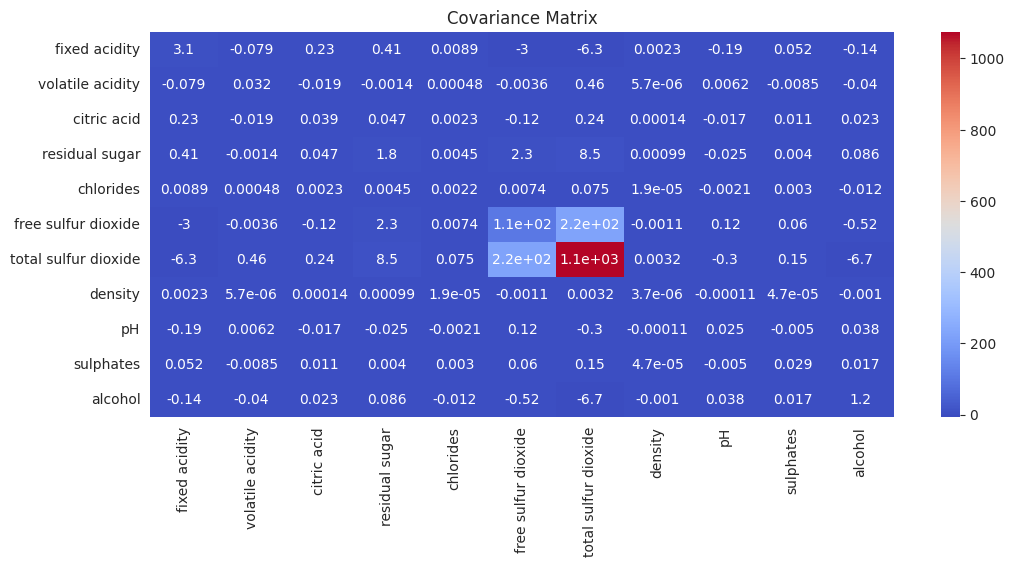

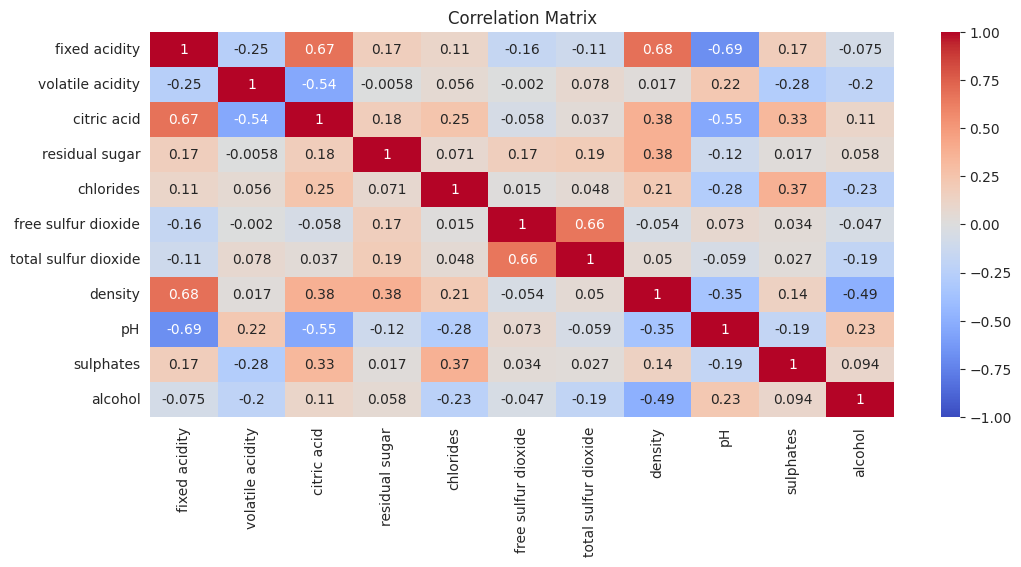

In [33]:
# Covariance Matrix & Correlation Matrix
var_list = features.columns.tolist()
p = len(var_list)

cov_matrix = np.zeros((p, p))
corr_matrix = np.zeros((p, p))
for i, vi in enumerate(var_list):
    for j, vj in enumerate(var_list):
        cov_matrix[i, j] = covariance(features[vi], features[vj], is_population=False)
        corr_matrix[i, j] = correlation(features[vi], features[vj])

plt.figure(figsize=(12, 5))
plt.subplot(1, 1, 1)
sns.heatmap(cov_matrix, annot=True, xticklabels=var_list, yticklabels=var_list, cmap="coolwarm")
plt.title("Covariance Matrix")
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 1, 1)
sns.heatmap(corr_matrix, annot=True, xticklabels=var_list, yticklabels=var_list, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

## Visualization


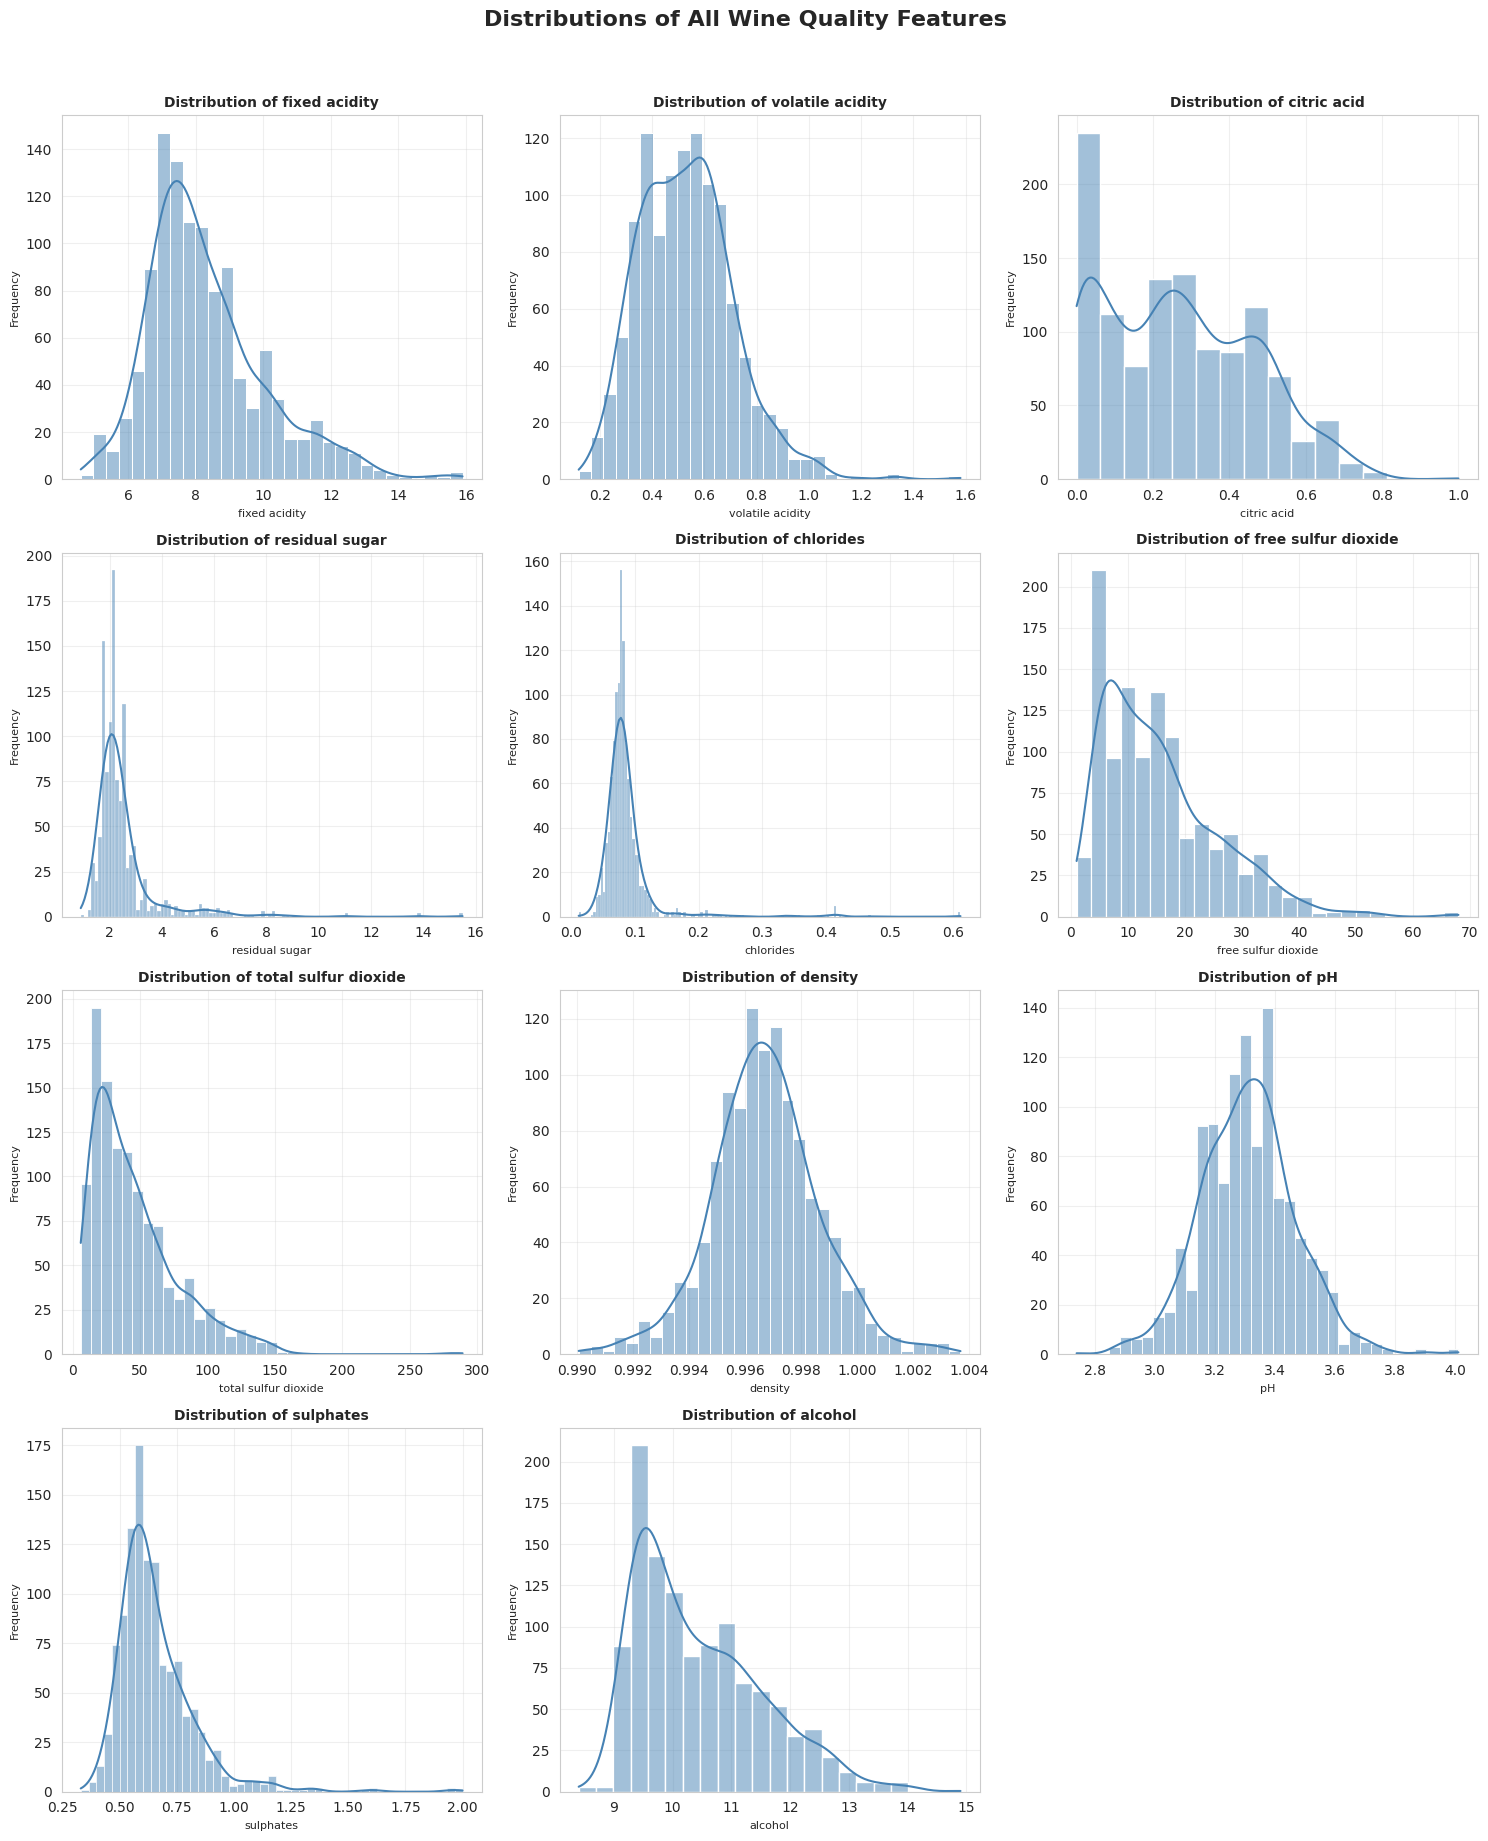

In [34]:
# Show distribution for all 11 features in subplots
plt.figure(figsize=(15, 18))
for i, col in enumerate(features.columns):
    plt.subplot(4, 3, i + 1)
    distribution(features, col)
plt.suptitle("Distributions of All Wine Quality Features", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

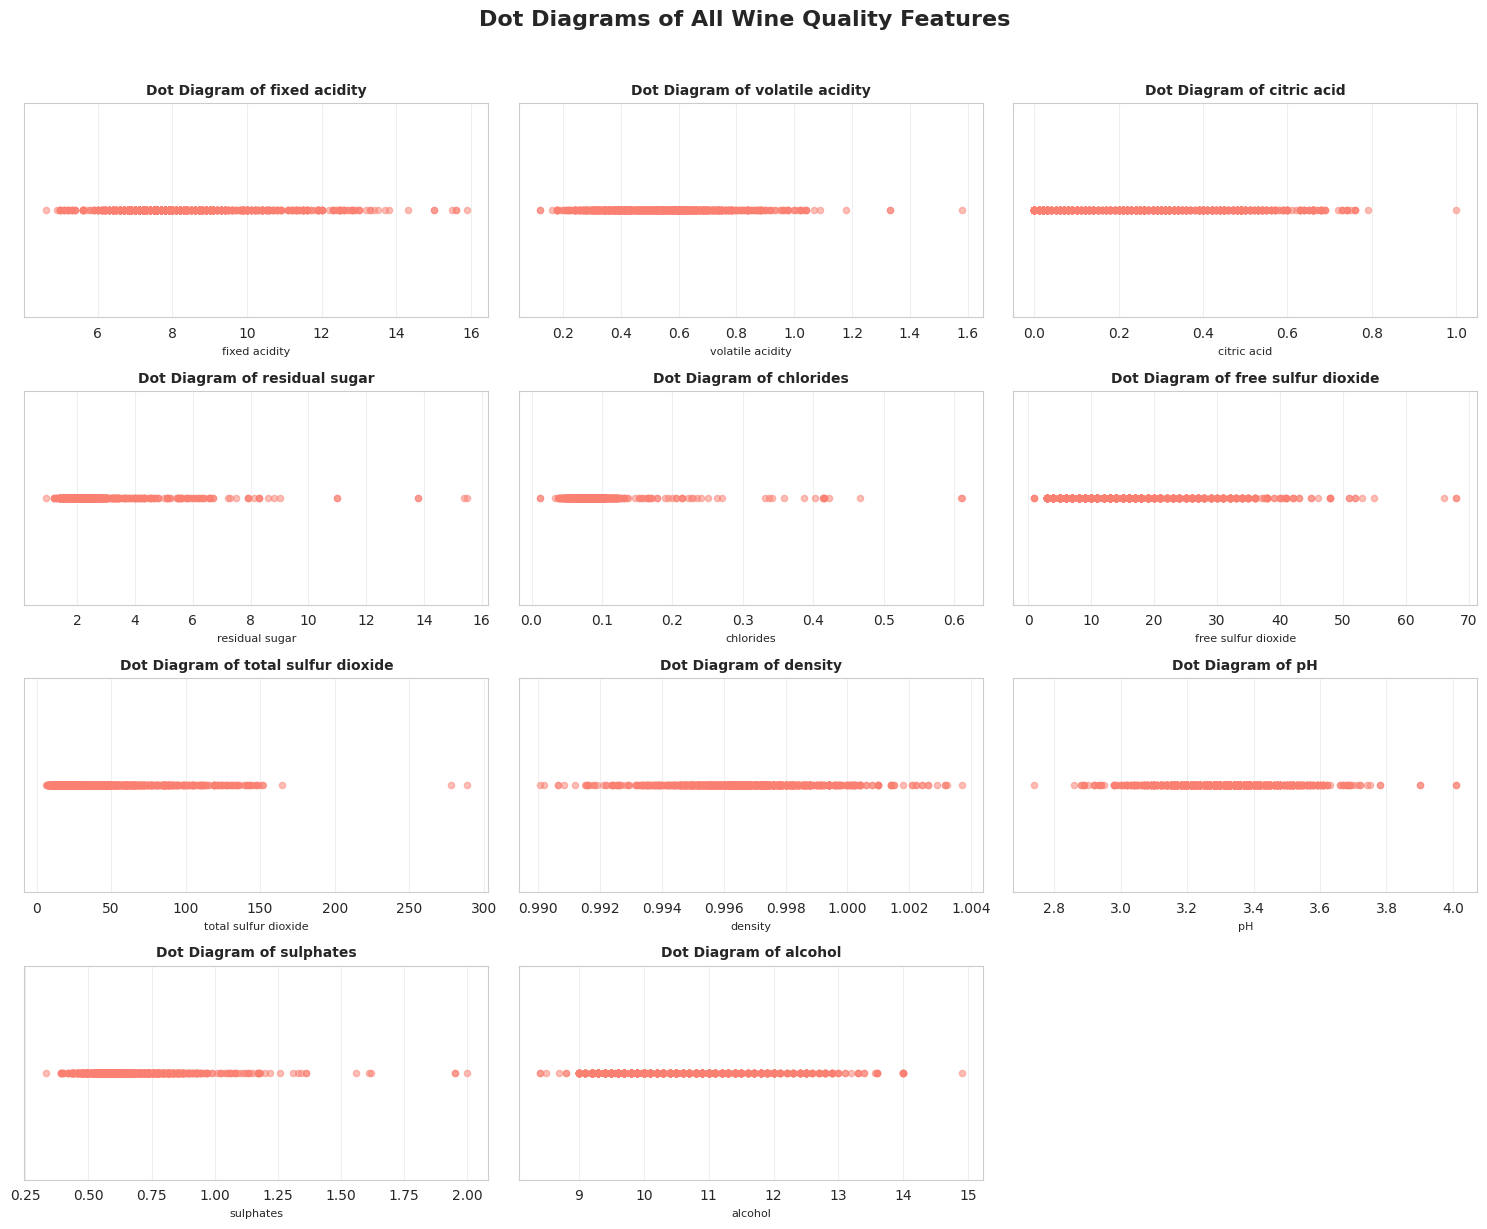

In [35]:
# Show dot diagram for all 11 features in subplots
plt.figure(figsize=(15, 12))
for i, col in enumerate(features.columns):
    plt.subplot(4, 3, i + 1)
    dot_diagram(features, col)
plt.suptitle("Dot Diagrams of All Wine Quality Features", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

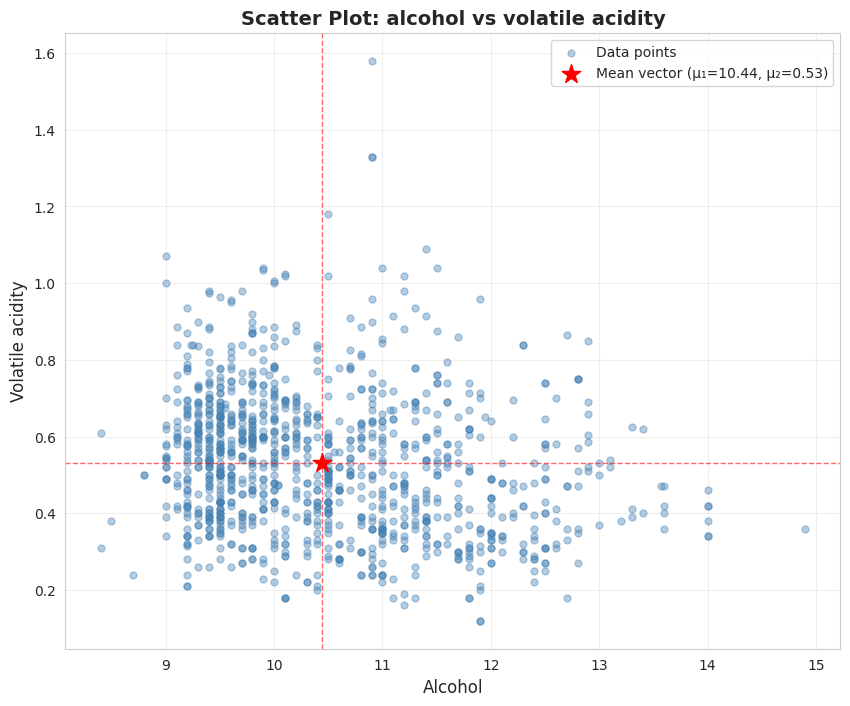

In [36]:
# Scatter plot for alcohol vs volatile acidity
plt.figure(figsize=(10, 8))
scatter_plot(features, "alcohol", "volatile acidity")
plt.show()

In [37]:
# Minh hoạ ý nghĩa hình học với 2 biến: alcohol & volatile acidity
v1_name, v2_name = "alcohol", "volatile acidity"
v1 = features[v1_name].values
v2 = features[v2_name].values
x1_bar, x2_bar = pop_mean[v1_name], pop_mean[v2_name]

d1 = v1 - x1_bar   
d2 = v2 - x2_bar
L1 = np.sqrt(np.dot(d1, d1))
L2 = np.sqrt(np.dot(d2, d2))
cos_theta = np.dot(d1, d2) / (L1 * L2)
theta_deg = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))

print(f"Biến 1: {v1_name}")
print(f"Mean = {x1_bar:.4f}")
print(f"Var  = {pop_var[v1_name]:.4f}")
print(f"Std  = {pop_std[v1_name]:.4f}")
print(f"||d1|| (Population Std × √n) = {L1:.4f}")
print()
print(f"Biến 2: {v2_name}")
print(f"Mean = {x2_bar:.4f}")
print(f"Var = {pop_var  [v2_name]:.4f}")
print(f"Std = {pop_std[v2_name]:.4f}")
print(f"||d2|| = {L2:.4f}")
print()
print(f"Góc θ giữa d1 và d2 = {theta_deg:.2f}°")
print(f"cos(θ) = r(alcohol, volatile acidity) = {cos_theta:.4f}")
print()
print(f"Xác nhận: correlation() = {correlation(features[v1_name], features[v2_name]):.4f}")

Biến 1: alcohol
Mean = 10.4421
Var  = 1.1711
Std  = 1.0822
||d1|| (Population Std × √n) = 36.5712

Biến 2: volatile acidity
Mean = 0.5313
Var = 0.0323
Std = 0.1796
||d2|| = 6.0704

Góc θ giữa d1 và d2 = 101.77°
cos(θ) = r(alcohol, volatile acidity) = -0.2039

Xác nhận: correlation() = -0.2039
